# Import Scripts and Load the Merged Data

In [1]:
import os
import sys

PROJECT_ROOT = os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
# merge the four datasets
from src.data.build_dataset import build_market_dataset

df = build_market_dataset()
df.head()

,date,SPY,QQQ,DIA,IWN
0,2002-01-03,1.127519,3.406775,0.975425,1.156449
1,2002-01-04,0.665375,0.408802,0.857495,0.847332
2,2002-01-07,-0.708118,-1.110050,-0.612907,-1.100651
3,2002-01-08,-0.231511,0.677149,-0.457057,0.803877
4,2002-01-09,-0.818595,-0.920103,-0.557779,-0.389629


In [3]:
df.shape

(6021, 5)

In [4]:
df.describe()

,date,SPY,QQQ,DIA,IWN
count,6021,6021.000000,6021.000000,6021.000000,6021.000000
mean,2014-01-16 08:07:24.843049472,0.039695,0.047040,0.026213,0.033360
min,2002-01-03 00:00:00,-11.588661,-12.759215,-13.841813,-14.064349
25%,2008-01-03 00:00:00,-0.422976,-0.591504,-0.436183,-0.686882
50%,2013-12-24 00:00:00,0.071503,0.114323,0.053446,0.068304
75%,2020-02-24 00:00:00,0.587825,0.760659,0.549566,0.809751
max,2026-02-19 00:00:00,19.985740,11.479906,10.764325,9.062167
std,NaN,1.230961,1.438580,1.146539,1.518730


<Axes: >

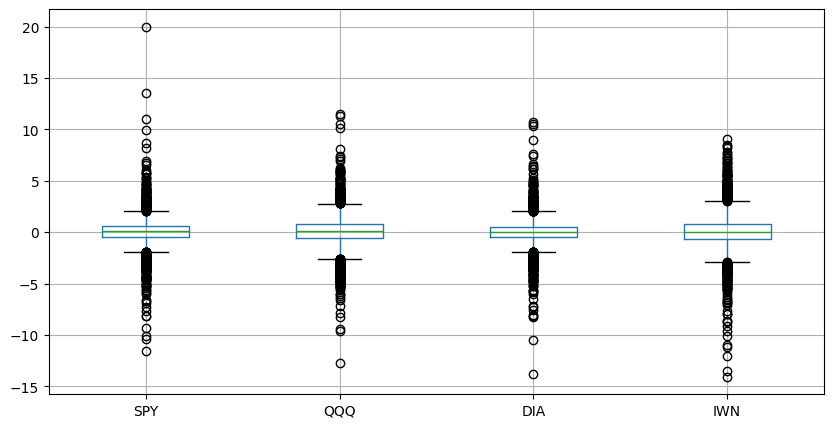

In [5]:
# inspecting tails
df.boxplot(figsize=(10,5))

we can see many assymetric tails and outliers beyond whiskers, which is our motivation to do flexible innovations

# Base VAR Test

In [6]:
from src.models.base_var import BaseVAR

var = BaseVAR(p=2, intercept=True)
design = var.build_design(df)

print("X shape:", design.X.shape)
print("Y shape:", design.Y.shape)
print("Dates shape:", design.dates.shape)
print("First 10 feature names:", design.feature_names[:10])

X shape: (6019, 9)
Y shape: (6019, 4)
Dates shape: (6019,)
First 10 feature names: ['intercept', 'SPY_lag1', 'QQQ_lag1', 'DIA_lag1', 'IWN_lag1', 'SPY_lag2', 'QQQ_lag2', 'DIA_lag2', 'IWN_lag2']


# Gaussian VAR w/ OLS

In [7]:
from src.models.gaussian_var import GaussianVAR

model = GaussianVAR(p=2, intercept=True)
result = model.fit(df)
model.summary()

{'p': 2,
 'intercept': True,
 'n_obs_effective': 6019,
 'n_series': 4,
 'n_features': 9,
 'beta_shape': (4, 9),
 'sigma_shape': (4, 4)}

In [8]:
# beta arrays
result.beta

array([[ 0.04311883, -0.1029961 ,  0.06385784, -0.11649409,  0.0506284 ,
        -0.15856426,  0.03770797,  0.10461545,  0.01598129],
       [ 0.0508339 , -0.06736029,  0.04724364, -0.14437008,  0.03799702,
        -0.06919901, -0.01367544,  0.04324064,  0.02465317],
       [ 0.02911379, -0.04233525,  0.05104918, -0.16824403,  0.04356329,
        -0.13023644,  0.02619027,  0.09074788,  0.01830084],
       [ 0.03615277, -0.02674738,  0.02883894, -0.11921913, -0.00435677,
        -0.10383296,  0.01271791,  0.15804461, -0.02301459]])

In [9]:
# error arrays
result.sigma

array([[1.49909795, 1.55237343, 1.30805722, 1.55111705],
       [1.55237343, 2.04912709, 1.36198586, 1.59823901],
       [1.30805722, 1.36198586, 1.29636837, 1.46314855],
       [1.55111705, 1.59823901, 1.46314855, 2.28447442]])

In [10]:
import pandas as pd

# residuals DF
resid_df = pd.DataFrame(
    result.residuals,
    columns=["SPY", "QQQ", "DIA", "IWN"]
)

resid_df.head()

,SPY,QQQ,DIA,IWN
0,-0.722021,-0.989853,-0.579428,-1.078674
1,-0.305513,0.578061,-0.532025,0.650799
2,-1.011459,-1.125598,-0.730566,-0.490362
3,0.299072,0.519585,-0.374976,0.004374
4,-1.089657,-1.416004,-0.915524,-1.083217


In [11]:
resid_df.kurtosis()

SPY    22.566209
QQQ     5.637562
DIA    12.693664
IWN     7.510998
dtype: float64

Kurtosis > 3, justifies use of T-Var

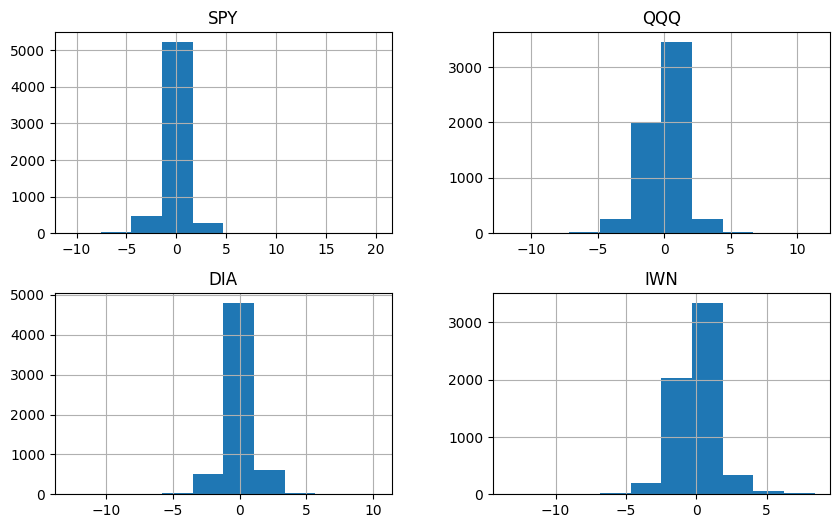

In [12]:
import matplotlib.pyplot as plt

resid_df.hist(figsize=(10, 6))
plt.show()

# Student t-VAR

It uses the standard scale-mixture representation:

- $\varepsilon_t \mid \lambda_t \sim \mathcal{N}(0, \Sigma / \lambda_t)$

- $\lambda_t \sim \text{Gamma}(\nu/2,\nu/2)$

and fits the model with a simple Gibbs sampler:

- sample $\beta$ by weighted least squares

- sample $\Sigma$ from residuals
	
- sample latent scales $\lambda_t$


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from src.data.build_dataset import build_market_dataset
from src.models.student_t_var import StudentTVAR

df = build_market_dataset()

model_t = StudentTVAR(p=2, intercept=True, nu=8, seed=123)
result_t = model_t.fit(df, n_iter=800, burn=300)

model_t.summary()

{'p': 2,
 'intercept': True,
 'nu': 8.0,
 'n_saved_draws': 500,
 'n_obs_effective': 6019,
 'n_series': 4,
 'n_features': 9,
 'beta_draw_shape': (4, 9),
 'sigma_draw_shape': (4, 4)}

In [3]:
beta_mean = model_t.posterior_mean_beta()
print(beta_mean)

[[ 0.07678809 -0.03746885  0.02575905 -0.06867602  0.01614879  0.00456455
  -0.00612163  0.0190525  -0.01872983]
 [ 0.09917369  0.01617924 -0.00105543 -0.08571939  0.01461504  0.04461496
  -0.02742605 -0.01353899 -0.01078229]
 [ 0.05712613  0.03440435  0.00788736 -0.12052098  0.0103322   0.01379111
  -0.0058124   0.01322823 -0.0160372 ]
 [ 0.06675527  0.04927198  0.00076607 -0.08950308 -0.02165132  0.07299449
  -0.02286211  0.02276491 -0.05754926]]


In [4]:
sigma_mean = model_t.posterior_mean_sigma()
print(sigma_mean)

[[0.7166144  0.81562496 0.64842841 0.8035225 ]
 [0.81562496 1.13601418 0.70169771 0.87028289]
 [0.64842841 0.70169771 0.64765873 0.74511776]
 [0.8035225  0.87028289 0.74511776 1.2621124 ]]


In [5]:
lam_last = result_t.lambda_draws[-1]

print("lambda min:", lam_last.min())
print("lambda max:", lam_last.max())
print("lambda mean:", lam_last.mean())

lambda min: 0.000835401276552475
lambda max: 4.555393402270686
lambda mean: 1.0021429127961687


In [6]:
import pandas as pd

resid_df = pd.DataFrame(
    result_t.residuals_last,
    columns=["SPY", "QQQ", "DIA", "IWN"]
)

print(resid_df.describe())

               SPY          QQQ          DIA          IWN
count  6019.000000  6019.000000  6019.000000  6019.000000
mean     -0.034959    -0.053439    -0.028265    -0.039044
std       1.226448     1.434618     1.141059     1.514643
min     -11.171716   -12.447704   -13.274388   -13.579467
25%      -0.500833    -0.687486    -0.491787    -0.763311
50%       0.011128     0.016588     0.005463    -0.002139
75%       0.512127     0.661465     0.488034     0.735809
max      19.979395    11.352496    10.504248     8.786957


In [7]:
print(resid_df.kurtosis())

SPY    23.242287
QQQ     6.106910
DIA    13.701918
IWN     8.016897
dtype: float64


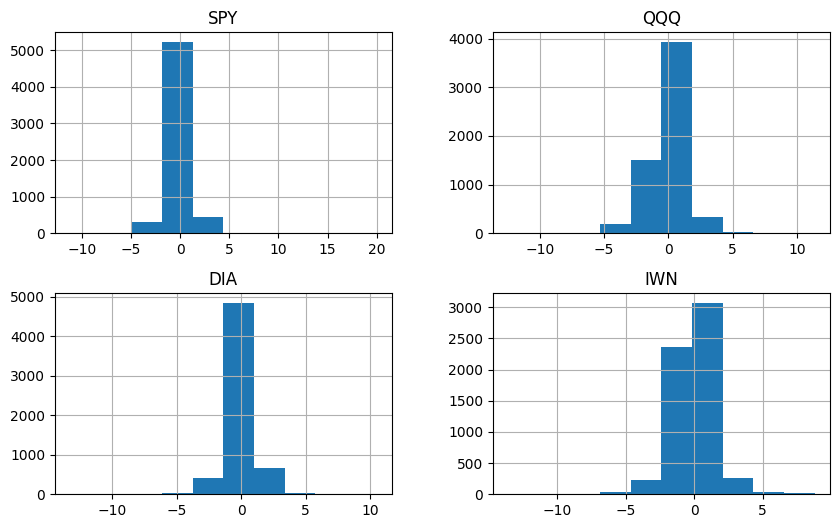

In [8]:
import matplotlib.pyplot as plt

resid_df.hist(figsize=(10,6))
plt.show()

In [9]:
print(len(result_t.beta_draws))
print(len(result_t.sigma_draws))

500
500


In [10]:
import numpy as np

np.mean([np.linalg.norm(b) for b in result_t.beta_draws])

np.float64(0.29011863434277185)

# Mixture VAR

This is the model where the innovation distribution is:

$$
\varepsilon_t \sim \sum_{k=1}^K \pi_k \mathcal{N}(0,\Sigma_k)
$$

with latent regime indicator:

$$
z_t \in {1,\dots,K}
$$

So each time point belongs to a latent shock regime, and each regime has its own covariance structure.

In [11]:
from src.data.build_dataset import build_market_dataset
from src.models.mixture_var import MixtureVAR

df = build_market_dataset()

mix_model = MixtureVAR(
    p=2,
    intercept=True,
    n_components=2,
    seed=123
)

mix_result = mix_model.fit(df, n_iter=800, burn=300)
mix_model.summary()

{'p': 2,
 'intercept': True,
 'n_components': 2,
 'n_saved_draws': 500,
 'n_obs_effective': 6019,
 'n_series': 4,
 'n_features': 9,
 'beta_draw_shape': (4, 9),
 'sigma_draw_shape': (2, 4, 4),
 'pi_draw_shape': (2,),
 'z_draw_shape': (6019,)}

In [12]:
# posterior regime weights
mix_model.posterior_mean_pi()

array([0.88131777, 0.11868223])

In [13]:
# post covariance by regime
sigma_mix = mix_model.posterior_mean_sigma()
sigma_mix.shape

(2, 4, 4)

In [14]:
sigma_mix[0]
sigma_mix[1]

array([[ 7.75286756,  7.4113802 ,  6.63995196,  7.51353837],
       [ 7.4113802 ,  9.24004047,  6.686682  ,  7.29903451],
       [ 6.63995196,  6.686682  ,  6.53457773,  7.23591869],
       [ 7.51353837,  7.29903451,  7.23591869, 10.29756084]])

In [15]:
# regime assignments
z_last = mix_result.z_draws[-1]
np.bincount(z_last)

array([5303,  716])

In [16]:
import pandas as pd

regime_df = pd.DataFrame({
    "date": mix_result.design.dates,
    "z": z_last
})

regime_df.head()

,date,z
0,2002-01-07,0
1,2002-01-08,0
2,2002-01-09,0
3,2002-01-10,0
4,2002-01-11,0


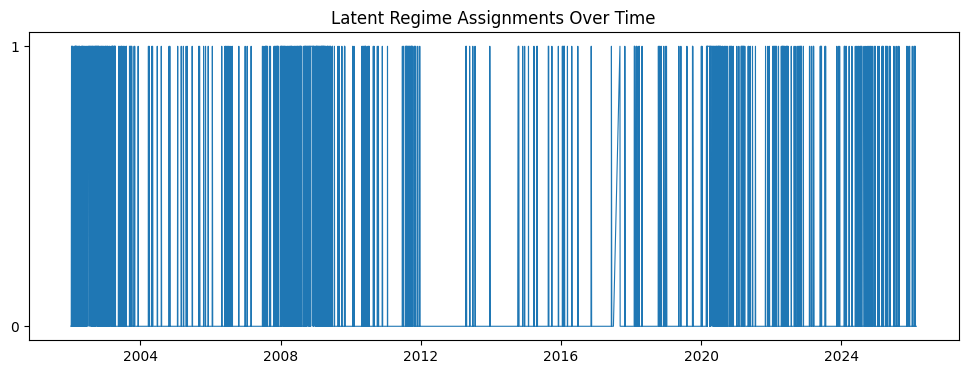

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(regime_df["date"], regime_df["z"], lw=0.8)
plt.title("Latent Regime Assignments Over Time")
plt.yticks([0, 1])
plt.show()

In [18]:
# one step predictive mean
Y = df.drop(columns="date").to_numpy()
last_obs = Y[-2:, :]

mix_model.forecast_one_step_mean(last_obs)

array([0.11920777, 0.1424151 , 0.12215547, 0.1158807 ])

In [19]:
# simulate the PPD
mix_sims = mix_model.simulate_one_step(last_obs, n_sim=2000)
mix_sims.shape

(2000, 4)

In [20]:
sigma_mix = mix_model.posterior_mean_sigma()

print("Regime 0 covariance:")
print(sigma_mix[0])

print("\nRegime 1 covariance:")
print(sigma_mix[1])

Regime 0 covariance:
[[0.6661755  0.77544429 0.59936414 0.76020708]
 [0.77544429 1.09934026 0.65765489 0.84669828]
 [0.59936414 0.65765489 0.60087667 0.69857328]
 [0.76020708 0.84669828 0.69857328 1.22409144]]

Regime 1 covariance:
[[ 7.75286756  7.4113802   6.63995196  7.51353837]
 [ 7.4113802   9.24004047  6.686682    7.29903451]
 [ 6.63995196  6.686682    6.53457773  7.23591869]
 [ 7.51353837  7.29903451  7.23591869 10.29756084]]


We can see from this that covariance explodes in response to market stress, which is consistent with econometrics

In [21]:
regime_df["z"].value_counts(normalize=True)
regime_df[(regime_df["date"] > "2008-01-01") & (regime_df["date"] < "2009-12-31")]

,date,z
1502,2008-01-02,1
1503,2008-01-03,0
1504,2008-01-04,1
1505,2008-01-07,0
1506,2008-01-08,0
...,...,...
2001,2009-12-23,0
2002,2009-12-24,0
2003,2009-12-28,0
2004,2009-12-29,0


In [22]:
regime_df[(regime_df["date"] > "2020-02-01") & (regime_df["date"] < "2020-06-01")]

,date,z
4499,2020-02-03,0
4500,2020-02-04,0
4501,2020-02-05,0
4502,2020-02-06,0
4503,2020-02-07,0
...,...,...
4576,2020-05-22,0
4577,2020-05-26,1
4578,2020-05-27,1
4579,2020-05-28,0


# Stoch. Vol. VAR

Build a VAR with time-varying innovation variance:

$$
y_t = Bx_t + \varepsilon_t,\qquad \varepsilon_t \sim \mathcal N(0,\Sigma_t)
$$

To keep this tractable, we’ll use a diagonal stochastic volatility version first:

$$
\Sigma_t = \mathrm{diag}(\exp(h_{t,1}), \dots, \exp(h_{t,d}))
$$

with latent log-volatility states following AR(1)-style dynamics:

$$
h_{t,j} = \mu_j + \phi_j(h_{t-1,j}-\mu_j) + \eta_{t,j}, \qquad \eta_{t,j}\sim \mathcal N(0,\sigma_{h,j}^2)
$$


In [23]:
from src.data.build_dataset import build_market_dataset
from src.models.sv_var import SVVAR

df = build_market_dataset()

sv_model = SVVAR(
    p=2,
    intercept=True,
    phi=0.98,
    sigma_h=0.15,
    seed=123,
)

sv_result = sv_model.fit(df, n_iter=800, burn=300)
sv_model.summary()

{'p': 2,
 'intercept': True,
 'phi': 0.98,
 'sigma_h': 0.15,
 'n_saved_draws': 500,
 'n_obs_effective': 6019,
 'n_series': 4,
 'n_features': 9,
 'beta_draw_shape': (4, 9),
 'h_draw_shape': (6019, 4)}

In [24]:
# post mean log vol
h_mean = sv_model.posterior_mean_h()
h_mean.shape

(6019, 4)

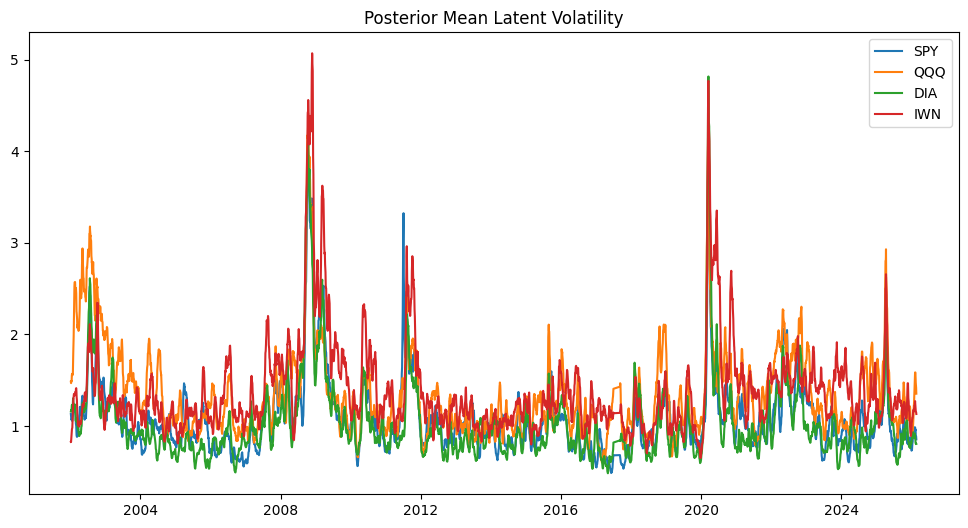

In [25]:
# latent volatility over time
import matplotlib.pyplot as plt
import numpy as np

dates = sv_result.design.dates

plt.figure(figsize=(12, 6))
for j, name in enumerate(["SPY", "QQQ", "DIA", "IWN"]):
    plt.plot(dates, np.exp(h_mean[:, j] / 2), label=name)

plt.title("Posterior Mean Latent Volatility")
plt.legend()
plt.show()

In [26]:
# one step pred mean
Y = df.drop(columns="date").to_numpy()
last_obs = Y[-2:, :]

sv_model.forecast_one_step_mean(last_obs)

array([0.10253626, 0.13000449, 0.11731912, 0.1008434 ])

In [27]:
# PPD draws
sv_sims = sv_model.simulate_one_step(last_obs, n_sim=2000)
sv_sims.shape

(2000, 4)